# Fake Review Detection Project

**Dataset:** YelpChi (Yelp restaurant reviews)  
---



## Table of Content
1. Imports & Configuration  
2. Data Loading  
3. Column Definitions & Stratified Split  
4. Feature Fusion Ablation Study  
5. Pipeline Definitions (with Calibration)  
6. Cross-Validation Comparison  
7. Hyperparameter Tuning  
8. Probability Calibration  
9. Dynamic Threshold Optimisation  
10. Final Test-Set Evaluation (Confusion Matrix · ROC · PR)  
11. Learning Curves  
12. Granular Error Analysis (FP / FN)  
13. SHAP Explainability  
14. Real-World Imbalance Simulation  
15. Save Artefacts  
16. Final Summary

## 1 — Imports & Configuration

In [1]:
# ── Google Colab: uncomment to install missing packages ───────────────────────
# !pip install xgboost shap --quiet

import os, re, json, time, copy, warnings, logging
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

import numpy as np
import pandas as pd

# ── NLP ────────────────────────────────────────────────────────────────────────
import nltk
for r in ('punkt', 'stopwords', 'wordnet', 'punkt_tab'):
    nltk.download(r, quiet=True)

# ── Sklearn — pipelines & transforms ─────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import RobustScaler, MaxAbsScaler
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

# ── Sklearn — classifiers ─────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# ── Sklearn — model selection ─────────────────────────────────────────────────
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, cross_val_score,
    train_test_split, RandomizedSearchCV, learning_curve
)
from sklearn.utils.class_weight import compute_class_weight

# ── Sklearn — metrics ─────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

# ── Scipy ─────────────────────────────────────────────────────────────────────
from scipy.sparse import issparse

# ── XGBoost ───────────────────────────────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    logging.warning("XGBoost not installed — run: pip install xgboost")

# ── SHAP ──────────────────────────────────────────────────────────────────────
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    logging.warning("SHAP not installed — run: pip install shap")

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 180,
    'figure.autolayout': True,
    'font.family': 'DejaVu Sans',
})

# ── Serialisation ─────────────────────────────────────────────────────────────
import joblib

print("All imports successful.")
print(f"  XGBoost : {'available' if XGBOOST_AVAILABLE else 'NOT installed (pip install xgboost)'}")
print(f"  SHAP    : {'available' if SHAP_AVAILABLE else 'NOT installed (pip install shap)'}")

All imports successful.
  XGBoost : available
  SHAP    : available


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL CONFIGURATION — all constants in one place for reproducibility
# ─────────────────────────────────────────────────────────────────────────────

RANDOM_STATE   = 42        # single seed used everywhere
TEST_SIZE      = 0.20      # 20% hold-out test partition
VAL_SIZE       = 0.20      # 20% validation (carved from train+val)
CV_FOLDS       = 5         # stratified k-fold
MAX_TFIDF_FEAT = 3_000     # vocabulary cap (prevents overwhelming behavioral features)
N_ITER_SEARCH  = 25        # RandomizedSearchCV iterations
N_JOBS         = -1        # all CPU cores
SCORING        = 'f1'      # primary optimisation metric

DATA_PATH = 'new_data_test.csv'   # update path if using Colab / Drive

# ── Output directories ────────────────────────────────────────────────────────
BASE_OUT = Path('outputs_final')
PLOT_DIR = BASE_OUT / 'plots'
MDL_DIR  = BASE_OUT / 'models'
ERR_DIR  = BASE_OUT / 'error_analysis'
for d in [PLOT_DIR, MDL_DIR, ERR_DIR]:
    d.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_STATE)

print(f"Configuration loaded.")
print(f"  Output root : {BASE_OUT.resolve()}")
print(f"  Random seed : {RANDOM_STATE}")

Configuration loaded.
  Output root : /content/outputs_final
  Random seed : 42


## 2 — Data Loading

In [3]:
def load_dataset(filepath: str) -> pd.DataFrame:
    """Load the YelpChi TSV and print a class-balance summary."""
    df    = pd.read_csv(filepath, sep='\t', index_col=0)
    total = len(df)
    n0    = (df['flagged'] == 0).sum()
    n1    = (df['flagged'] == 1).sum()
    print("=" * 65)
    print("  Dataset Summary")
    print("=" * 65)
    print(f"  Records    : {total:,}")
    print(f"  Genuine(0) : {n0:,}  ({n0/total*100:.1f}%)")
    print(f"  Fake   (1) : {n1:,}  ({n1/total*100:.1f}%)")
    print(f"  Imbalance  : {n0/n1:.2f}:1  (genuine:fake)")
    if n0/n1 < 1.5:
        print("  -> Near-balanced. class_weight='balanced' applied as safeguard.")
    else:
        print("  -> Imbalance detected. class_weight='balanced' applied.")
    return df

df = load_dataset(DATA_PATH)
df.head(3)

  Dataset Summary
  Records    : 2,483
  Genuine(0) : 1,212  (48.8%)
  Fake   (1) : 1,271  (51.2%)
  Imbalance  : 0.95:1  (genuine:fake)
  -> Near-balanced. class_weight='balanced' applied as safeguard.


,reviewID,reviewerID,restaurantID,date,rating,reviewUsefulCount,reviewContent,flagged,name,location,...,reviewCount,firstCount,usefulCount,coolCount,funnyCount,complimentCount,tipCount,fanCount,restaurantRating,ReviewLength
7267,dLS_UUea0Yh7et2YlGpUOw,hfQu0YNy_XW5oiiripgUFg,8d_DiHWB-pjBVW3a7D8EWg,1/25/2012,4,0,sunda amazing i heard many good things finally...,1,Mallory M.,"Chicago, IL",...,1,0,0,0,0,0,0,0,4.0,72
731,EDejgdY32F8Lr4ewh7FeiA,_jsZl-USMgrVVasNg50wAQ,boE4Ahsssqic7o5wQLI04w,5/5/2012,4,0,absolutely fantastic foodie community table gr...,0,Shawn K.,"Davenport, FL",...,1,0,0,0,0,0,5,0,4.0,12
9902,TRLtyGBT7VFODhxgyZ2tLA,sZxXpvmBUN2fSCtK_BZFoQ,ms5ge1XY9-Alu7HkybAMdQ,11/9/2007,3,0,i work right rarely go here they 5 personal st...,0,Dane K.,"Chicago, IL",...,845,143,2499,1451,1151,1377,2,55,3.5,102


  Exploratory Data Analysis (EDA)

  Missing Values Analysis:


,Missing Values,Percentage (%)
location,2,0.080548
reviewID,0,0.000000
restaurantID,0,0.000000
date,0,0.000000
rating,0,0.000000



  Duplicate rows: 0


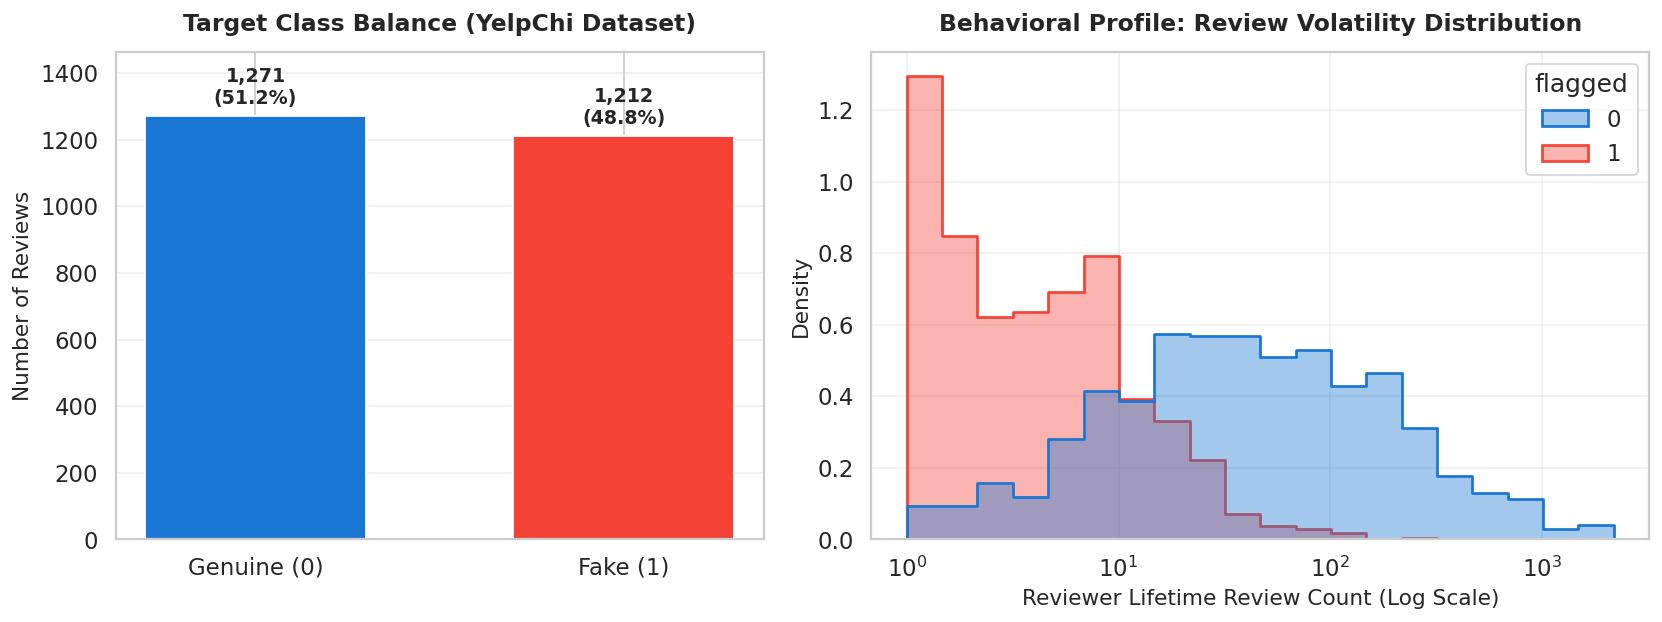


  EDA visualisations saved -> outputs_final/plots/eda_summary.png


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2.5 — Exploratory Data Analysis (EDA)
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("  Exploratory Data Analysis (EDA)")
print("=" * 65)

# 1. Programmatic Missing Value Check
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Missing Values', ascending=False)
print("\n  Missing Values Analysis:")
display(missing_summary.head(5))

# 1b. Duplicate Row Check
print(f"\n  Duplicate rows: {df.duplicated().sum()}")

# 2. Plotting Class Balance & Behavioral Distribution (Side-by-Side)
fig = plt.figure(figsize=(13, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2])

# Left Plot: Clean, publication-quality Class Balance Chart
ax0 = fig.add_subplot(gs[0])
class_counts = df['flagged'].value_counts()
colors = ['#1976D2', '#F44336']  # Matches your pipeline's blue/red theme
bars = ax0.bar(['Genuine (0)', 'Fake (1)'], class_counts.values, color=colors, edgecolor='white', width=0.6)

# Annotate bars with values and percentages
for bar in bars:
    height = bar.get_height()
    pct = (height / len(df)) * 100
    ax0.text(bar.get_x() + bar.get_width()/2, height + (len(df) * 0.01),
             f'{height:,}\n({pct:.1f}%)', ha='center', va='bottom',
             fontsize=10.5, fontweight='bold')
ax0.set_ylabel('Number of Reviews', fontsize=12)
ax0.set_title('Target Class Balance (YelpChi Dataset)', fontweight='bold', fontsize=13, pad=12)
ax0.set_ylim(0, max(class_counts.values) * 1.15)
ax0.grid(True, axis='y', alpha=0.3)

# Right Plot: Feature distribution highlighting why RobustScaler is necessary
ax1 = fig.add_subplot(gs[1])
# Log-transform just for EDA visualization because behavioral counts have massive outliers
sns.histplot(data=df, x='reviewCount', hue='flagged', ax=ax1,
             palette=['#1976D2', '#F44336'], log_scale=True,
             element='step', stat='density', common_norm=False, alpha=0.4, linewidth=1.5)
ax1.set_xlabel('Reviewer Lifetime Review Count (Log Scale)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Behavioral Profile: Review Volatility Distribution', fontweight='bold', fontsize=13, pad=12)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'eda_summary.png', bbox_inches='tight', dpi=180)
plt.show()
print(f"\n  EDA visualisations saved -> {PLOT_DIR / 'eda_summary.png'}")

## 3 — Column Definitions & Stratified Split

> **Zero-leakage guarantee:** `TfidfVectorizer` and `RobustScaler` are
> defined here but **never** called on the full dataset. All `.fit()` calls
> happen strictly inside `Pipeline.fit(X_train, ...)` or inside cross-validation
> folds. The test set is not seen until Section 10.

In [5]:
TEXT_COL   = 'reviewContent'
TARGET_COL = 'flagged'

# All numerical reviewer-metadata columns in YelpChi
BEHAVIORAL_COLS = [c for c in [
    'friendCount', 'reviewCount', 'firstCount',
    'usefulCount', 'coolCount', 'funnyCount',
    'complimentCount', 'tipCount', 'fanCount',
    'reviewUsefulCount', 'rating', 'restaurantRating',
] if c in df.columns]

# ── Data cleaning (no leakage — only type coercion, no statistics computed) ──
df[BEHAVIORAL_COLS] = (
    df[BEHAVIORAL_COLS]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(df[BEHAVIORAL_COLS].median())
)
df[TEXT_COL] = df[TEXT_COL].fillna('').astype(str)

print(f"Text column       : '{TEXT_COL}'")
print(f"Behavioral cols   : {BEHAVIORAL_COLS}")
print(f"Shape after prep  : {df.shape}")

# ── Stratified 60 / 20 / 20 split ────────────────────────────────────────────
X = df[[TEXT_COL] + BEHAVIORAL_COLS].copy()
y = df[TARGET_COL].copy()

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

val_frac = VAL_SIZE / (1 - TEST_SIZE)   # fraction of tv to use as val
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=val_frac, stratify=y_tv, random_state=RANDOM_STATE)

total = len(y)
for split, ys in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"  {split:<6}: {len(ys):,} ({len(ys)/total*100:.0f}%)  "
          f"fake={ys.mean()*100:.1f}%")

# Class weights (computed on train only)
_cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
CLASS_WEIGHT = {0: float(_cw[0]), 1: float(_cw[1])}
print(f"  Class weights : {CLASS_WEIGHT}")

Text column       : 'reviewContent'
Behavioral cols   : ['friendCount', 'reviewCount', 'firstCount', 'usefulCount', 'coolCount', 'funnyCount', 'complimentCount', 'tipCount', 'fanCount', 'reviewUsefulCount', 'rating', 'restaurantRating']
Shape after prep  : (2483, 22)
  Train : 1,489 (60%)  fake=51.2%
  Val   : 497 (20%)  fake=51.3%
  Test  : 497 (20%)  fake=51.1%
  Class weights : {0: 1.0240715268225584, 1: 0.9770341207349081}


## 4 — Feature Fusion Ablation Study

Quantifies the contribution of each modality using `LogisticRegression`
in a 5-fold stratified CV loop. All transforms are **inside** the pipeline.

| Config | TF-IDF | RobustScaler |
|---|---|---|
| Text-only | Yes (3 k features) | No |
| Behavioral-only | No | Yes |
| Fusion (combined) | Yes | Yes (via `ColumnTransformer`) |

  Ablation Study — 5-fold CV (train set, Logistic Regression)
  Config                        F1       ±       AUC
  ----------------------------------------------------
  Text-only                 62.61%   2.74%     66.58%
  Behavioral-only           78.88%   2.67%     90.89%
  Fusion (combined)         74.97%   2.46%     90.88%


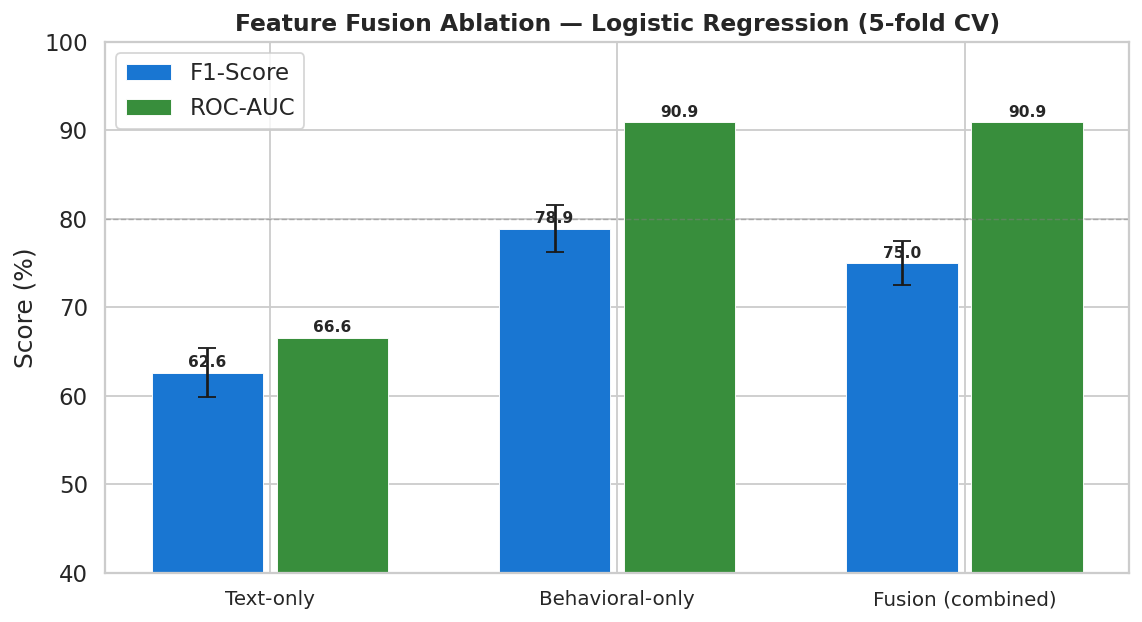


Ablation plot saved.


In [6]:
def _fusion_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('text', TfidfVectorizer(
                max_features=MAX_TFIDF_FEAT, sublinear_tf=True,
                ngram_range=(1, 2), min_df=2, max_df=0.95), TEXT_COL),
            ('behavioral', RobustScaler(), BEHAVIORAL_COLS),
        ],
        remainder='drop', sparse_threshold=0.3
    )

def _lr():
    return LogisticRegression(
        solver='saga', max_iter=1000,
        class_weight='balanced', random_state=RANDOM_STATE)

ablation_pipes = {
    'Text-only': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=MAX_TFIDF_FEAT,
                                   sublinear_tf=True, ngram_range=(1,2),
                                   min_df=2, max_df=0.95)),
        ('clf', _lr())]),
    'Behavioral-only': Pipeline([
        ('scaler', RobustScaler()),
        ('clf', _lr())]),
    'Fusion (combined)': Pipeline([
        ('preprocessor', _fusion_preprocessor()),
        ('clf', _lr())]),
}

def _X(name, split):
    """Route correct data slice to each pipeline type."""
    if name == 'Text-only':
        return split[TEXT_COL]
    elif name == 'Behavioral-only':
        return split[BEHAVIORAL_COLS]
    return split   # Fusion receives the full DataFrame

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
ablation_results = {}

print("=" * 62)
print("  Ablation Study — 5-fold CV (train set, Logistic Regression)")
print("=" * 62)
print(f"  {'Config':<22} {'F1':>9} {'±':>7} {'AUC':>9}")
print("  " + "-" * 52)

for name, pipe in ablation_pipes.items():
    Xtr = _X(name, X_train)
    f1s  = cross_val_score(pipe, Xtr, y_train, cv=skf, scoring='f1',      n_jobs=N_JOBS)
    aucs = cross_val_score(pipe, Xtr, y_train, cv=skf, scoring='roc_auc', n_jobs=N_JOBS)
    ablation_results[name] = {'F1': f1s.mean(), 'F1_std': f1s.std(), 'AUC': aucs.mean()}
    print(f"  {name:<22} {f1s.mean()*100:>8.2f}%  {f1s.std()*100:>5.2f}%  {aucs.mean()*100:>8.2f}%")

# Plot
configs = list(ablation_results)
f1v  = [ablation_results[c]['F1']*100   for c in configs]
aucv = [ablation_results[c]['AUC']*100  for c in configs]
std  = [ablation_results[c]['F1_std']*100 for c in configs]
x    = np.arange(len(configs))

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x-0.18, f1v,  0.32, label='F1-Score', color='#1976D2',
            yerr=std, capsize=5, edgecolor='white', linewidth=0.5)
b2 = ax.bar(x+0.18, aucv, 0.32, label='ROC-AUC',  color='#388E3C',
            edgecolor='white', linewidth=0.5)
for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.1f}', ha='center',
            va='bottom', fontsize=8.5, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(configs, fontsize=11)
ax.set_ylim(40, 100); ax.set_ylabel('Score (%)')
ax.set_title('Feature Fusion Ablation — Logistic Regression (5-fold CV)',
             fontweight='bold', fontsize=13)
ax.axhline(80, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'ablation_study.png', bbox_inches='tight')
plt.show()
print("\nAblation plot saved.")

## 5 — Full Pipeline Definitions

> **Calibration strategy:** `CalibratedClassifierCV` is applied **after**
> hyperparameter tuning (Section 7) using `cv='prefit'` so that the final
> tuned estimator is wrapped in calibration without retuning. This avoids
> the complex double-prefix parameter naming (`clf__estimator__param`) during
> `RandomizedSearchCV`.
>
> **NB compatibility:** `ComplementNB` requires non-negative input.
> `RobustScaler` centres data (median = 0) and can produce negative values.
> The NB pipeline therefore uses text-only TF-IDF features, which are always
> non-negative — the standard approach for Naive Bayes text classifiers.

In [7]:
def build_pipelines() -> dict:
    """
    Return un-fitted pipeline templates for all classifiers.
    Calibration wrappers are added in Section 8 after tuning.
    All transforms are encapsulated — zero global state.
    """
    fp = _fusion_preprocessor   # shorthand

    pipes = {}

    # Logistic Regression — fusion
    pipes['Logistic Regression'] = Pipeline([
        ('preprocessor', fp()),
        ('clf', LogisticRegression(
            solver='saga', max_iter=1000,
            class_weight='balanced', random_state=RANDOM_STATE))
    ])

    # Complement Naive Bayes — text-only (NB requires non-negative features)
    pipes['Complement NB'] = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=MAX_TFIDF_FEAT, sublinear_tf=True,
            ngram_range=(1,2), min_df=2, max_df=0.95)),
        ('clf', ComplementNB(alpha=0.1))
    ])

    # LinearSVC — fusion (wrapped in CalibratedClassifierCV for predict_proba)
    pipes['SVM (Linear)'] = Pipeline([
        ('preprocessor', fp()),
        ('clf', CalibratedClassifierCV(
            LinearSVC(class_weight='balanced', max_iter=3000,
                      random_state=RANDOM_STATE),
            cv=3))
    ])

    # Random Forest — fusion
    pipes['Random Forest'] = Pipeline([
        ('preprocessor', fp()),
        ('clf', RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=N_JOBS))
    ])

    # XGBoost — fusion (calibration added post-tuning in Section 8)
    if XGBOOST_AVAILABLE:
        pos_w = CLASS_WEIGHT[1] / CLASS_WEIGHT[0]
        pipes['XGBoost'] = Pipeline([
            ('preprocessor', fp()),
            ('clf', XGBClassifier(
                n_estimators=200, learning_rate=0.1, max_depth=6,
                scale_pos_weight=pos_w, eval_metric='logloss',
                random_state=RANDOM_STATE, n_jobs=N_JOBS))
        ])

    return pipes


PIPELINES = build_pipelines()

def get_X(name, split):
    """Return correct feature slice for each pipeline type."""
    return split[TEXT_COL] if name == 'Complement NB' else split

print("Pipelines defined:")
for n in PIPELINES:
    print(f"  [{n}]  input={'text-only' if n=='Complement NB' else 'fusion'}")

Pipelines defined:
  [Logistic Regression]  input=fusion
  [Complement NB]  input=text-only
  [SVM (Linear)]  input=fusion
  [Random Forest]  input=fusion
  [XGBoost]  input=fusion


## 6 — Cross-Validation Comparison (Train Set)

In [8]:
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print("=" * 74)
print("  5-Fold Stratified CV — Baseline Pipelines (train set)")
print("=" * 74)
print(f"  {'Model':<26} {'F1 Mean':>9} {'F1 Std':>8} {'AUC Mean':>10}  {'Time':>6}")
print("  " + "-" * 65)

cv_rows = []
for name, pipe in PIPELINES.items():
    Xtr = get_X(name, X_train)
    t0  = time.time()
    res = cross_validate(pipe, Xtr, y_train, cv=skf, n_jobs=N_JOBS,
                         scoring=['f1', 'roc_auc', 'accuracy'],
                         return_train_score=False)
    elapsed = time.time() - t0
    row = {
        'Model'        : name,
        'F1 Mean (%)'  : round(res['test_f1'].mean()      * 100, 2),
        'F1 Std (%)'   : round(res['test_f1'].std()       * 100, 2),
        'AUC Mean (%)' : round(res['test_roc_auc'].mean() * 100, 2),
        'Acc Mean (%)' : round(res['test_accuracy'].mean()* 100, 2),
    }
    cv_rows.append(row)
    print(f"  {name:<26} {row['F1 Mean (%)']:>8.2f}%  "
          f"{row['F1 Std (%)']:>6.2f}%  {row['AUC Mean (%)']:>9.2f}%  {elapsed:>5.1f}s")

cv_df = pd.DataFrame(cv_rows).sort_values('F1 Mean (%)', ascending=False)
print()
display(cv_df)

  5-Fold Stratified CV — Baseline Pipelines (train set)
  Model                        F1 Mean   F1 Std   AUC Mean    Time
  -----------------------------------------------------------------
  Logistic Regression           74.97%    2.46%      90.88%    5.8s
  Complement NB                 61.30%    1.88%      66.57%    1.5s
  SVM (Linear)                  84.78%    1.39%      87.85%    4.6s
  Random Forest                 86.33%    0.68%      91.58%    6.5s
  XGBoost                       84.95%    0.41%      91.80%   15.3s



,Model,F1 Mean (%),F1 Std (%),AUC Mean (%),Acc Mean (%)
3,Random Forest,86.33,0.68,91.58,85.23
4,XGBoost,84.95,0.41,91.80,84.22
2,SVM (Linear),84.78,1.39,87.85,82.07
0,Logistic Regression,74.97,2.46,90.88,77.90
1,Complement NB,61.30,1.88,66.57,62.46


## 7 — Hyperparameter Tuning (RandomizedSearchCV)

> All tuning operates on the **training set only** via stratified k-fold.
> The validation and test sets are never seen during tuning.

In [9]:
PARAM_GRIDS = {
    'Logistic Regression': {
        'clf__C'      : [0.01, 0.1, 1.0, 5.0, 10.0, 50.0],
        'clf__penalty': ['l2'],
        'preprocessor__text__ngram_range' : [(1,1),(1,2),(1,3)],
        'preprocessor__text__max_features': [2000, 3000, 5000],
    },
    'Random Forest': {
        'clf__n_estimators'     : [100, 200, 300],
        'clf__max_depth'        : [None, 10, 20, 30],
        'clf__min_samples_split': [2, 5, 10],
        'clf__max_features'     : ['sqrt', 'log2'],
    },
    'XGBoost': {
        'clf__n_estimators'   : [100, 200, 300],
        'clf__max_depth'      : [3, 5, 6, 8],
        'clf__learning_rate'  : [0.01, 0.05, 0.1, 0.2],
        'clf__subsample'      : [0.7, 0.85, 1.0],
        'clf__colsample_bytree': [0.7, 0.85, 1.0],
    },
}

tuned_pipelines = {}

for name, pipe in PIPELINES.items():
    Xtr = get_X(name, X_train)
    if name not in PARAM_GRIDS:
        # Fit as-is (SVM already calibrated; NB has no complex grid)
        print(f"  Fitting {name} (no tuning)...")
        pipe.fit(Xtr, y_train)
        tuned_pipelines[name] = pipe
        continue

    print(f"  Tuning {name}...")
    t0     = time.time()
    search = RandomizedSearchCV(
        pipe, PARAM_GRIDS[name], n_iter=N_ITER_SEARCH,
        scoring=SCORING, cv=skf, n_jobs=N_JOBS,
        random_state=RANDOM_STATE, refit=True, verbose=0)
    search.fit(Xtr, y_train)
    elapsed = time.time() - t0
    print(f"    Best CV F1  : {search.best_score_*100:.2f}%  ({elapsed:.1f}s)")
    print(f"    Best params : {search.best_params_}")
    tuned_pipelines[name] = search.best_estimator_

print("\nTuning complete. All pipelines fitted on X_train.")

  Tuning Logistic Regression...
    Best CV F1  : 75.16%  (149.5s)
    Best params : {'preprocessor__text__ngram_range': (1, 1), 'preprocessor__text__max_features': 2000, 'clf__penalty': 'l2', 'clf__C': 50.0}
  Fitting Complement NB (no tuning)...
  Fitting SVM (Linear) (no tuning)...
  Tuning Random Forest...
    Best CV F1  : 86.77%  (105.9s)
    Best params : {'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__max_features': 'sqrt', 'clf__max_depth': 30}
  Tuning XGBoost...
    Best CV F1  : 86.78%  (276.6s)
    Best params : {'clf__subsample': 0.85, 'clf__n_estimators': 200, 'clf__max_depth': 3, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.85}

Tuning complete. All pipelines fitted on X_train.


## 8 — Probability Calibration

> Tree-based models (Random Forest, XGBoost) and LinearSVC tend to produce
> over-confident probabilities out of the box. `CalibratedClassifierCV` with
> `method='isotonic'` (non-parametric) is applied using `cv='prefit'` so the
> already-tuned estimator is wrapped without re-fitting.
>
> Fitting the calibration layer on **X_val** (not X_train) gives an unbiased
> estimate of calibration quality. Calibration probabilities are used for all
> subsequent threshold optimisation and PR/ROC curves.

  Logistic Regression: no additional calibration needed.
  Complement NB: no additional calibration needed.
  SVM (Linear): no additional calibration needed.
  Calibrating Random Forest (isotonic, cv='prefit')...
  Calibrating XGBoost (isotonic, cv='prefit')...


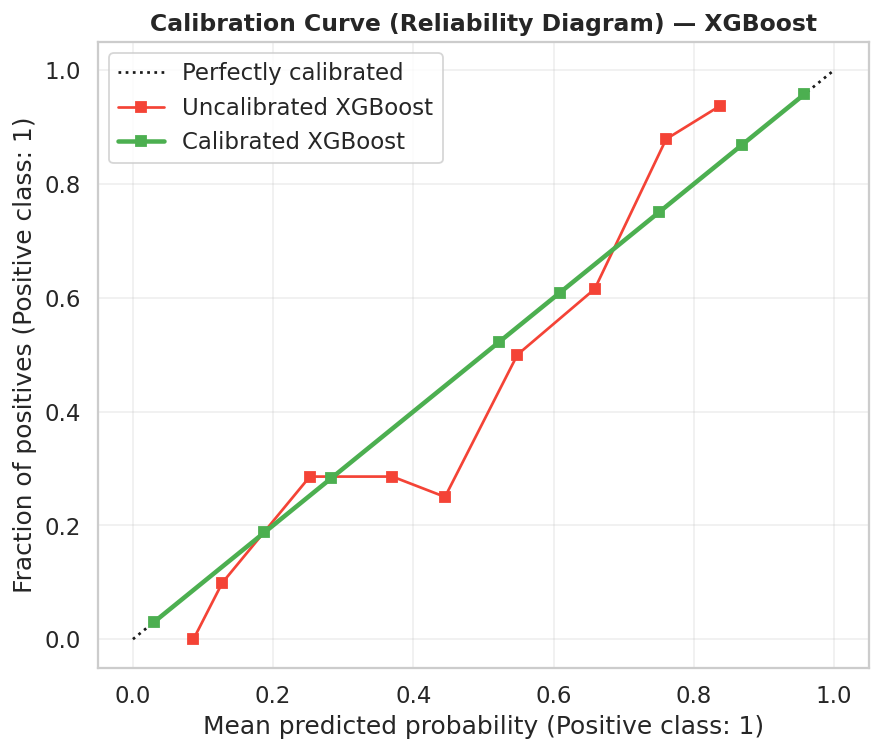

  Calibration curve saved.


In [10]:
def calibrate_pipeline(pipe, X_tr, y_tr, X_cal, y_cal, method='isotonic'):
    """
    Wrap the fitted pipeline in a CalibratedClassifierCV using cv='prefit'.
    The pipeline is treated as a single estimator — CalibratedClassifierCV
    will call pipe.predict_proba() internally for Platt / isotonic scaling.

    Parameters
    ----------
    pipe   : fitted sklearn Pipeline
    X_tr   : training features (used to refit for Platt scaling if cv != 'prefit')
    X_cal  : calibration features (validation set)
    y_cal  : calibration labels
    method : 'isotonic' (>=1000 samples) or 'sigmoid'
    """
    cal = CalibratedClassifierCV(pipe, method=method, cv='prefit')
    cal.fit(X_cal, y_cal)
    return cal


NEEDS_CALIBRATION = {'Random Forest', 'XGBoost'}
calibrated_pipelines = {}

for name, pipe in tuned_pipelines.items():
    Xcal = get_X(name, X_val)
    if name in NEEDS_CALIBRATION and hasattr(pipe, 'predict_proba'):
        print(f"  Calibrating {name} (isotonic, cv='prefit')...")
        calibrated_pipelines[name] = calibrate_pipeline(
            pipe, None, None, Xcal, y_val, method='isotonic')
    else:
        # LR, NB, SVM already calibrated or produce reliable probabilities
        calibrated_pipelines[name] = pipe
        print(f"  {name}: no additional calibration needed.")

# ── Calibration curve (reliability diagram) ───────────────────────────────────
if XGBOOST_AVAILABLE and 'XGBoost' in calibrated_pipelines:
    fig, ax = plt.subplots(figsize=(7, 6))
    Xte_cal = get_X('XGBoost', X_val)
    for obj, label, color, lw in [
        (tuned_pipelines['XGBoost'],      'Uncalibrated XGBoost', '#F44336', 1.5),
        (calibrated_pipelines['XGBoost'], 'Calibrated XGBoost',   '#4CAF50', 2.5),
    ]:
        CalibrationDisplay.from_estimator(
            obj, Xte_cal, y_val, n_bins=10, ax=ax, name=label,
            color=color, linewidth=lw)
    ax.set_title('Calibration Curve (Reliability Diagram) — XGBoost',
                 fontweight='bold', fontsize=13)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'calibration_curve.png', bbox_inches='tight')
    plt.show()
    print("  Calibration curve saved.")

## 9 — Dynamic Threshold Optimisation

> The default decision threshold of **0.5** is arbitrary and rarely optimal,
> especially when precision and recall are unevenly valued.
>
> We sweep the classification threshold over the **validation set** PR frontier
> and select the value that maximises F1-Score. The test set is **not** used
> here — using test data for threshold selection is a form of evaluation leakage.

Evaluating calibrated pipelines on validation set...
  Logistic Regression       : Val F1 = 79.64%
  Complement NB             : Val F1 = 67.48%
  SVM (Linear)              : Val F1 = 85.56%
  Random Forest             : Val F1 = 89.15%
  XGBoost                   : Val F1 = 88.80%

  Selected best model: Random Forest

Running threshold optimisation on validation set...


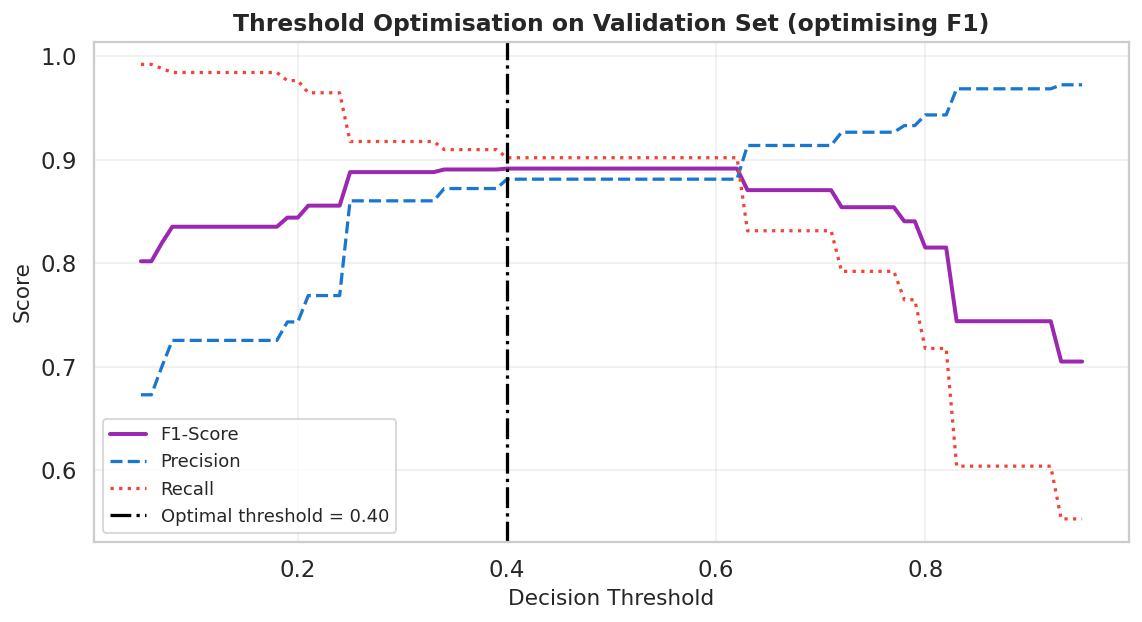

  Optimal threshold : 0.40
  Val F1 at optimal : 89.15%


In [11]:
def optimise_threshold(pipe, X_val, y_val, metric='f1'):
    """
    Find the classification threshold that maximises the chosen metric on the
    validation set. Sweeps [0.05, 0.95] in steps of 0.01.

    Returns
    -------
    best_thresh : float
    thresh_df   : DataFrame with Precision, Recall, F1 at each threshold
    """
    probs  = pipe.predict_proba(X_val)[:, 1]
    threshs = np.arange(0.05, 0.96, 0.01)
    records = []
    best_score, best_thresh = -1.0, 0.5

    for t in threshs:
        preds = (probs >= t).astype(int)
        f1    = f1_score(y_val, preds, zero_division=0)
        prec  = precision_score(y_val, preds, zero_division=0)
        rec   = recall_score(y_val, preds, zero_division=0)
        records.append({'Threshold': t, 'F1': f1, 'Precision': prec, 'Recall': rec})
        score = f1 if metric == 'f1' else (prec if metric == 'precision' else rec)
        if score > best_score:
            best_score, best_thresh = score, t

    thresh_df = pd.DataFrame(records)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(thresh_df['Threshold'], thresh_df['F1'],        lw=2.2,
            color='#9C27B0', label='F1-Score')
    ax.plot(thresh_df['Threshold'], thresh_df['Precision'], lw=1.8,
            color='#1976D2', label='Precision', linestyle='--')
    ax.plot(thresh_df['Threshold'], thresh_df['Recall'],    lw=1.8,
            color='#F44336', label='Recall',    linestyle=':')
    ax.axvline(best_thresh, color='black', lw=1.8, ls='-.',
               label=f'Optimal threshold = {best_thresh:.2f}')
    ax.set_xlabel('Decision Threshold', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'Threshold Optimisation on Validation Set '
                 f'(optimising {metric.upper()})', fontweight='bold', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'threshold_optimisation.png', bbox_inches='tight')
    plt.show()

    print(f"  Optimal threshold : {best_thresh:.2f}")
    print(f"  Val F1 at optimal : {best_score*100:.2f}%")
    return best_thresh, thresh_df


# ── Select best pipeline by validation F1 (default 0.5 threshold) ─────────────
print("Evaluating calibrated pipelines on validation set...")
val_f1s = {}
for name, pipe in calibrated_pipelines.items():
    Xv = get_X(name, X_val)
    pred = pipe.predict(Xv)
    val_f1s[name] = f1_score(y_val, pred, zero_division=0)
    print(f"  {name:<26}: Val F1 = {val_f1s[name]*100:.2f}%")

BEST_NAME = max(val_f1s, key=val_f1s.get)
BEST_PIPE = calibrated_pipelines[BEST_NAME]
print(f"\n  Selected best model: {BEST_NAME}")

# ── Optimise threshold for the best model ─────────────────────────────────────
print("\nRunning threshold optimisation on validation set...")
X_val_best = get_X(BEST_NAME, X_val)
OPTIMAL_THRESHOLD, thresh_df = optimise_threshold(BEST_PIPE, X_val_best, y_val)

## 10 — Final Test-Set Evaluation

> Test set evaluated **exactly once** using the optimal threshold from Section 9.
> Includes a publication-quality Seaborn confusion matrix heatmap, ROC curves
> for all models, and a Precision-Recall curve.

  Final Test-Set Evaluation  (threshold=0.40 for Random Forest)
  Model                          Acc    Prec     Rec      F1     AUC
  ---------------------------------------------------------------
  Logistic Regression         78.67%  90.66%  64.96%  75.69%  91.13%
  Complement NB               61.77%  63.91%  57.87%  60.74%  69.28%
  SVM (Linear)                84.71%  78.90%  95.67%  86.48%  90.54%
  Random Forest               86.32%  86.05%  87.40%  86.72%  92.08%
  XGBoost                     88.53%  86.08%  92.52%  89.18%  93.36%



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,XGBoost,88.53,86.08,92.52,89.18,93.36
3,Random Forest,86.32,86.05,87.40,86.72,92.08
2,SVM (Linear),84.71,78.90,95.67,86.48,90.54
0,Logistic Regression,78.67,90.66,64.96,75.69,91.13
1,Complement NB,61.77,63.91,57.87,60.74,69.28



  Classification Report (Random Forest, threshold=0.40):
              precision    recall  f1-score   support

     Genuine     0.8661    0.8519    0.8589       243
        Fake     0.8605    0.8740    0.8672       254

    accuracy                         0.8632       497
   macro avg     0.8633    0.8629    0.8631       497
weighted avg     0.8632    0.8632    0.8631       497



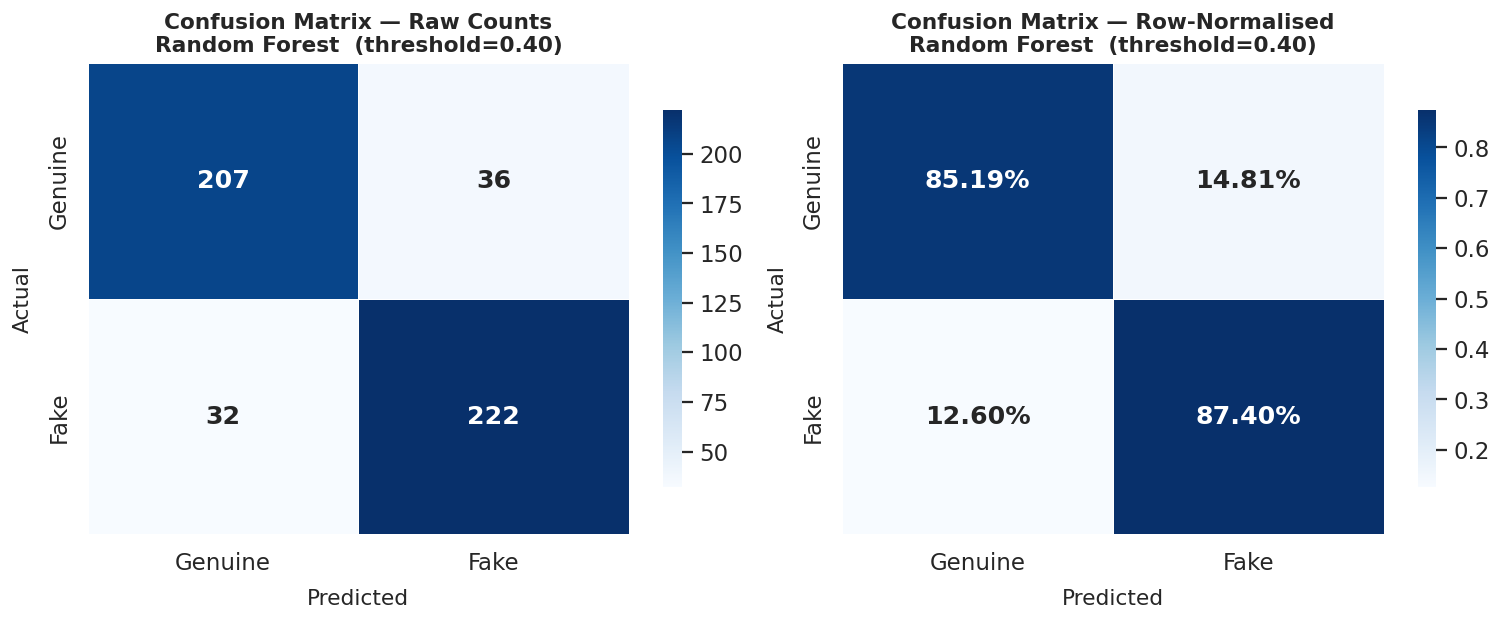

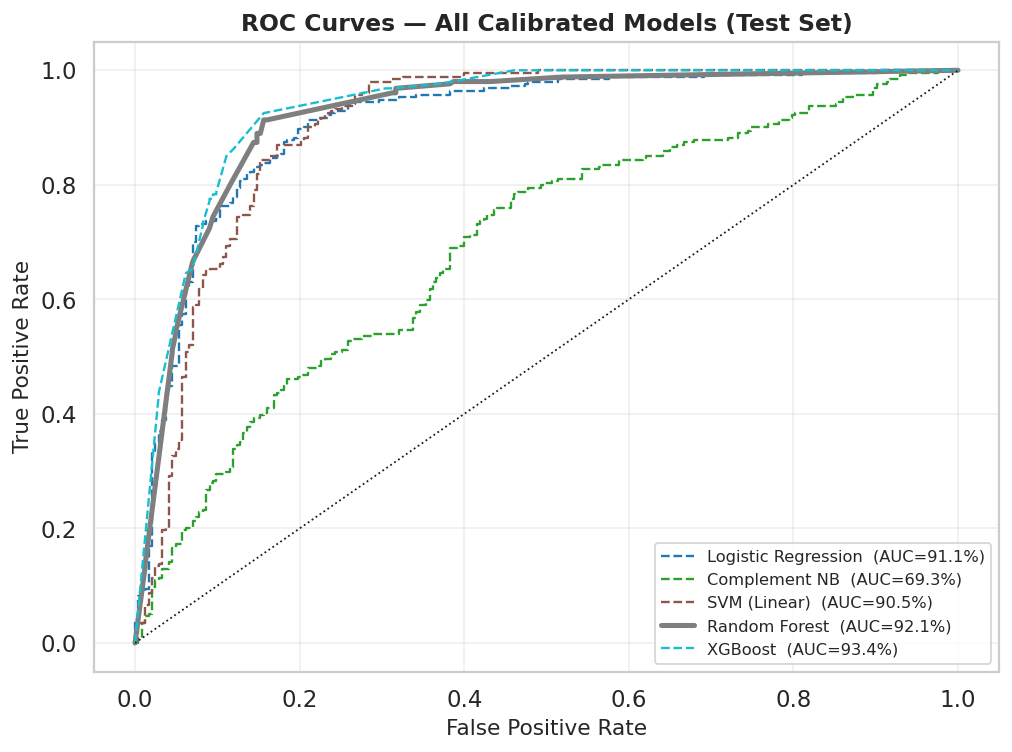

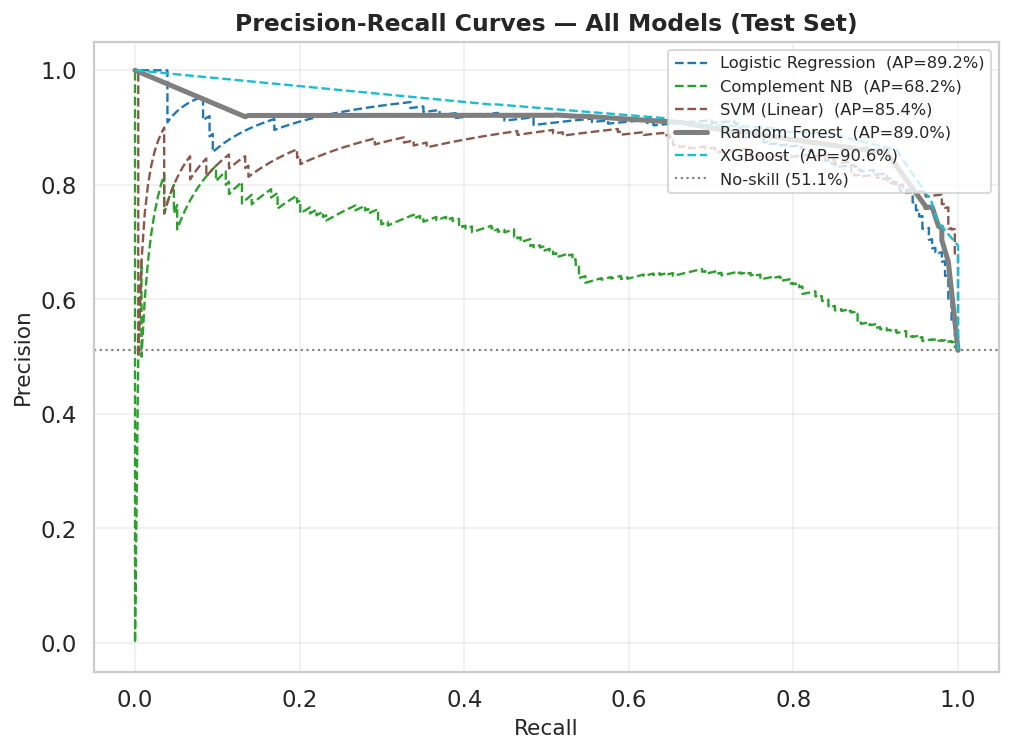

All evaluation plots saved.


In [12]:
# ── Generate test predictions for all models ──────────────────────────────────
def eval_on_test(name, pipe, threshold=0.5):
    Xte   = get_X(name, X_test)
    prob  = pipe.predict_proba(Xte)[:, 1] if hasattr(pipe,'predict_proba') else None
    pred  = (prob >= threshold).astype(int) if prob is not None else pipe.predict(Xte)
    return {
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test, pred)                * 100, 2),
        'Precision' : round(precision_score(y_test, pred, zero_division=0)*100, 2),
        'Recall'    : round(recall_score(y_test, pred, zero_division=0)  *100, 2),
        'F1-Score'  : round(f1_score(y_test, pred, zero_division=0)      *100, 2),
        'ROC-AUC'   : round(roc_auc_score(y_test, prob)*100, 2) if prob is not None else None,
        '_pred': pred, '_prob': prob,
    }

print("=" * 72)
print(f"  Final Test-Set Evaluation  (threshold={OPTIMAL_THRESHOLD:.2f} for {BEST_NAME})")
print("=" * 72)
print(f"  {'Model':<26} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
print("  " + "-" * 63)

test_results = []
for name, pipe in calibrated_pipelines.items():
    thresh = OPTIMAL_THRESHOLD if name == BEST_NAME else 0.5
    m = eval_on_test(name, pipe, threshold=thresh)
    test_results.append(m)
    auc_s = f"{m['ROC-AUC']:>6.2f}%" if m['ROC-AUC'] else "   N/A "
    print(f"  {name:<26} {m['Accuracy']:>6.2f}% {m['Precision']:>6.2f}% "
          f"{m['Recall']:>6.2f}% {m['F1-Score']:>6.2f}% {auc_s}")

best_result = next(r for r in test_results if r['Model'] == BEST_NAME)
results_df  = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')}
                              for r in test_results]).sort_values('F1-Score', ascending=False)
print()
display(results_df)

print(f"\n  Classification Report ({BEST_NAME}, threshold={OPTIMAL_THRESHOLD:.2f}):")
print(classification_report(y_test, best_result['_pred'],
                             target_names=['Genuine','Fake'], digits=4))

# ── Seaborn Confusion Matrix Heatmap ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, norm, fmt, title_sfx in [
    (axes[0], None,   'd',    'Raw Counts'),
    (axes[1], 'true', '.2%',  'Row-Normalised'),
]:
    cm  = confusion_matrix(y_test, best_result['_pred'], normalize=norm)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=['Genuine','Fake'], yticklabels=['Genuine','Fake'],
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'},
                cbar_kws={'shrink': 0.8})
    ax.set_xlabel('Predicted', fontsize=12, labelpad=8)
    ax.set_ylabel('Actual',    fontsize=12, labelpad=8)
    ax.set_title(f'Confusion Matrix — {title_sfx}\n{BEST_NAME}  '
                 f'(threshold={OPTIMAL_THRESHOLD:.2f})', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_matrix.png', bbox_inches='tight')
plt.show()

# ── ROC Curves — all models ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
color_cycle = plt.cm.tab10(np.linspace(0, 1, len(test_results)))
for r, col in zip(test_results, color_cycle):
    if r['_prob'] is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, r['_prob'])
    lw = 2.8 if r['Model'] == BEST_NAME else 1.3
    ls = '-'  if r['Model'] == BEST_NAME else '--'
    ax.plot(fpr, tpr, lw=lw, ls=ls, color=col,
            label=f"{r['Model']}  (AUC={r['ROC-AUC']:.1f}%)")
ax.plot([0,1],[0,1],'k:',lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — All Calibrated Models (Test Set)',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'roc_curves.png', bbox_inches='tight')
plt.show()

# ── Precision-Recall Curves — all models ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for r, col in zip(test_results, color_cycle):
    if r['_prob'] is None:
        continue
    prec, rec, _ = precision_recall_curve(y_test, r['_prob'])
    ap  = average_precision_score(y_test, r['_prob'])
    lw = 2.8 if r['Model'] == BEST_NAME else 1.3
    ls = '-'  if r['Model'] == BEST_NAME else '--'
    ax.plot(rec, prec, lw=lw, ls=ls, color=col,
            label=f"{r['Model']}  (AP={ap*100:.1f}%)")
ax.axhline(y_test.mean(), color='gray', ls=':', lw=1.2,
           label=f'No-skill ({y_test.mean()*100:.1f}%)')
ax.set_xlabel('Recall',    fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models (Test Set)',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'pr_curves.png', bbox_inches='tight')
plt.show()
print("All evaluation plots saved.")

## 11 — Learning Curves

> **Common mistake fixed:** `shuffle` and `random_state` must **not** be passed
> to `sklearn.learning_curve()` when `cv` is already a `StratifiedKFold` object —
> sklearn ≥ 1.0 raises `ValueError` in that case. Shuffling lives in the CV
> object only.
>
> `n_jobs=1` prevents multiprocessing pickling failures with calibrated estimators.

Generating learning curves...


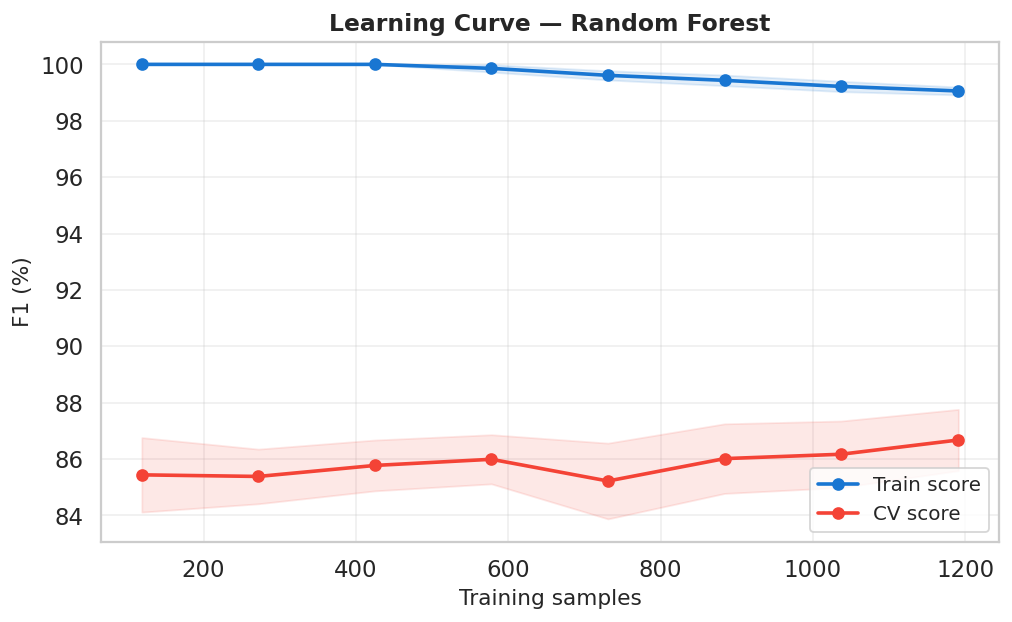

  Random Forest: train=99.1%  CV=86.7%  gap=12.4%


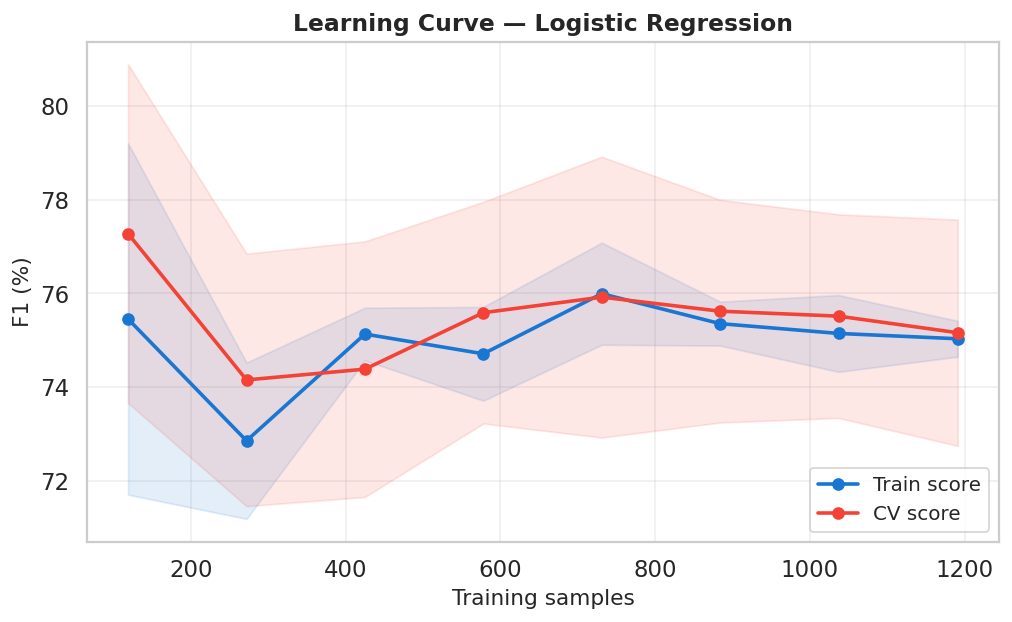

  Logistic Regression: train=75.0%  CV=75.2%  gap=-0.1%
Learning curves saved.


In [13]:
def plot_learning_curve(pipe, X_lc, y_lc, title, cv=5,
                         scoring='f1', n_points=8):
    """
    Plot training vs cross-validation score as training size grows.
    Uses n_jobs=1 to avoid pickling errors with CalibratedClassifierCV.
    Does NOT pass shuffle/random_state to learning_curve() — those live
    in the StratifiedKFold object.
    """
    skf_lc = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    sizes  = np.linspace(0.1, 1.0, n_points)

    try:
        sizes_abs, train_sc, val_sc = learning_curve(
            pipe, X_lc, y_lc,
            train_sizes=sizes,
            cv=skf_lc,
            scoring=scoring,
            n_jobs=1,          # avoids pickling errors with calibrated estimators
            error_score=0.0    # return 0 on a bad fold rather than crashing
        )
    except Exception as exc:
        print(f"  Warning: learning_curve failed for '{title}': {exc}")
        return

    tr_mean = train_sc.mean(axis=1) * 100
    tr_std  = train_sc.std(axis=1)  * 100
    va_mean = val_sc.mean(axis=1)   * 100
    va_std  = val_sc.std(axis=1)    * 100

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sizes_abs, tr_mean, 'o-', color='#1976D2', lw=2, label='Train score')
    ax.fill_between(sizes_abs, tr_mean-tr_std, tr_mean+tr_std,
                    alpha=0.12, color='#1976D2')
    ax.plot(sizes_abs, va_mean, 'o-', color='#F44336', lw=2, label='CV score')
    ax.fill_between(sizes_abs, va_mean-va_std, va_mean+va_std,
                    alpha=0.12, color='#F44336')
    ax.set_xlabel('Training samples', fontsize=12)
    ax.set_ylabel(f'{scoring.upper()} (%)', fontsize=12)
    ax.set_title(f'Learning Curve — {title}', fontweight='bold', fontsize=13)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    safe = title.replace(' ','_').replace('(','').replace(')','')
    plt.savefig(PLOT_DIR / f'learning_curve_{safe}.png', bbox_inches='tight')
    plt.show()
    print(f"  {title}: train={tr_mean[-1]:.1f}%  CV={va_mean[-1]:.1f}%  "
          f"gap={tr_mean[-1]-va_mean[-1]:.1f}%")


print("Generating learning curves...")
# Use the tuned (pre-calibration) pipeline for learning curves to avoid
# CalibratedClassifierCV(cv='prefit') re-fit issues inside learning_curve
for name in [BEST_NAME, 'Logistic Regression']:
    pipe_lc = tuned_pipelines.get(name)
    if pipe_lc is None:
        continue
    plot_learning_curve(
        pipe_lc, get_X(name, X_train), y_train,
        title=name, cv=CV_FOLDS)

print("Learning curves saved.")

## 12 — Granular Error Analysis

> Isolates **False Positives** (genuine reviews flagged as fake) and
> **False Negatives** (fake reviews that evaded detection).
> Exports both categories to CSV for manual linguistic inspection.

  Error Analysis
  Test samples    : 497
  Total errors    : 68  (13.7%)
  False Positives : 36  (genuine -> flagged as fake)
  False Negatives : 32  (fake -> missed by model)

  False Positives — review-length & rating summary:
       rating  reviewCount  friendCount
count   36.00        36.00        36.00
mean     3.97         7.31         3.06
std      1.34         5.76         7.68
min      1.00         1.00         0.00
25%      3.00         3.00         0.00
50%      5.00         5.50         0.00
75%      5.00         9.00         1.25
max      5.00        27.00        31.00

  False Negatives — review-length & rating summary:
       rating  reviewCount  friendCount
count   32.00        32.00        32.00
mean     3.78        30.56         6.91
std      1.41        24.71        16.71
min      1.00         3.00         0.00
25%      3.00        15.00         0.00
50%      4.00        22.00         1.00
75%      5.00        31.00         3.00
max      5.00        96.00        74.0

,reviewContent,error_type,true_label,confidence,rating
22423,in fact asian dishes hotpot really non formal ...,FP,0,1.000000,1
26658,this restaurant great the decor nice always go...,FP,0,1.000000,5
7986,the food pretty good omelets ok nothing specia...,FP,0,1.000000,3
5476,i intrigued iron chef jos茅 garces place decide...,FN,1,0.983333,4
9624,get pho bring white girl guy date,FN,1,0.983333,5
18672,i went friends days ago busy friday evening my...,FN,1,0.983333,4
5678,can t believe i lived chicago 3 years never kn...,FP,0,0.957895,5
4017,the churros rather disappointing they evidentl...,FP,0,0.957895,2
26672,wow place almost makes time stand still my wif...,FP,0,0.957895,4
11021,looking uncommon rip off right place unfortuna...,FP,0,0.957895,1



  FP saved -> outputs_final/error_analysis/false_positives.csv
  FN saved -> outputs_final/error_analysis/false_negatives.csv


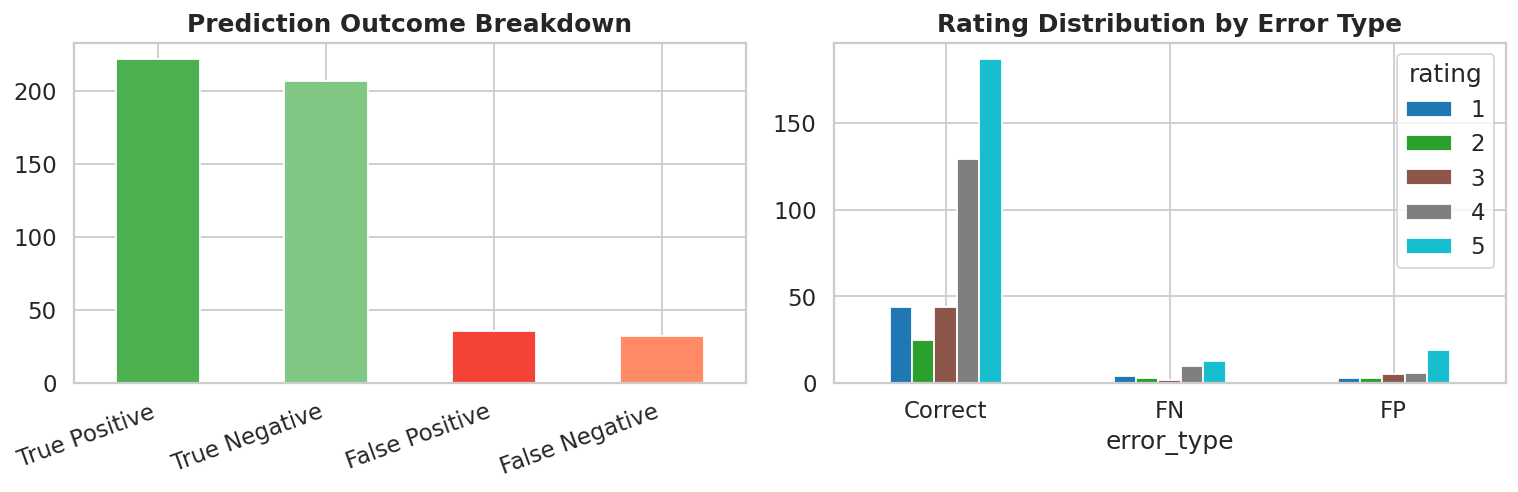

In [14]:
def error_analysis(df_full, test_idx, y_true, y_pred, y_prob,
                   top_confident=15):
    """
    Analyse misclassifications structurally.
    Returns FP and FN DataFrames; exports to CSV.
    """
    err = df_full.loc[test_idx, [TEXT_COL, 'flagged'] + BEHAVIORAL_COLS].copy()
    err['true_label'] = y_true.values
    err['pred_label'] = y_pred
    err['pred_prob']  = y_prob if y_prob is not None else 0.5
    err['error_type'] = 'Correct'
    err.loc[(err.true_label==0)&(err.pred_label==1), 'error_type'] = 'FP'
    err.loc[(err.true_label==1)&(err.pred_label==0), 'error_type'] = 'FN'

    fp_df = err[err.error_type=='FP']
    fn_df = err[err.error_type=='FN']
    total_err = len(fp_df) + len(fn_df)

    print("=" * 65)
    print("  Error Analysis")
    print("=" * 65)
    print(f"  Test samples    : {len(err):,}")
    print(f"  Total errors    : {total_err}  ({total_err/len(err)*100:.1f}%)")
    print(f"  False Positives : {len(fp_df)}  (genuine -> flagged as fake)")
    print(f"  False Negatives : {len(fn_df)}  (fake -> missed by model)")

    # ── Structural summaries ──────────────────────────────────────────────────
    for label, subset in [('False Positives', fp_df), ('False Negatives', fn_df)]:
        if len(subset) == 0:
            continue
        print(f"\n  {label} — review-length & rating summary:")
        if '_raw_length' in df_full.columns:
            subset = subset.copy()
            subset['review_length'] = df_full.loc[subset.index, '_raw_length']
        cols_show = ['rating', 'reviewCount', 'friendCount']
        cols_show = [c for c in cols_show if c in subset.columns]
        print(subset[cols_show].describe().round(2).to_string())

    # ── Highest-confidence errors ─────────────────────────────────────────────
    err_only = err[err.error_type != 'Correct'].copy()
    err_only['confidence'] = err_only.apply(
        lambda r: r['pred_prob'] if r['pred_label']==1 else 1-r['pred_prob'], axis=1)
    top_err = err_only.nlargest(top_confident, 'confidence')[
        [TEXT_COL, 'error_type', 'true_label', 'confidence', 'rating']]

    print(f"\n  Top-{top_confident} highest-confidence misclassifications:")
    display(top_err)

    # ── Export ───────────────────────────────────────────────────────────────
    fp_path = ERR_DIR / 'false_positives.csv'
    fn_path = ERR_DIR / 'false_negatives.csv'
    fp_df.to_csv(fp_path); print(f"\n  FP saved -> {fp_path}")
    fn_df.to_csv(fn_path); print(f"  FN saved -> {fn_path}")

    # ── Error-type breakdown bar chart ────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    pd.Series({'True Positive': (err.error_type=='Correct')&(err.true_label==1),
               'True Negative': (err.error_type=='Correct')&(err.true_label==0),
               'False Positive': err.error_type=='FP',
               'False Negative': err.error_type=='FN'}).map(sum).plot.bar(
        ax=axes[0], color=['#4CAF50','#81C784','#F44336','#FF8A65'],
        edgecolor='white')
    axes[0].set_title('Prediction Outcome Breakdown', fontweight='bold')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')

    if 'rating' in err.columns:
        err.groupby(['error_type','rating']).size().unstack(fill_value=0).plot.bar(
            ax=axes[1], colormap='tab10', edgecolor='white')
        axes[1].set_title('Rating Distribution by Error Type', fontweight='bold')
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'error_analysis.png', bbox_inches='tight')
    plt.show()
    return fp_df, fn_df


fp_df, fn_df = error_analysis(
    df, X_test.index, y_test,
    best_result['_pred'], best_result['_prob']
)

## 13 — SHAP Explainability (XAI)

> **Sparse-matrix fix (critical):** sklearn `ColumnTransformer` returns a sparse
> matrix when the TF-IDF portion dominates. `shap.TreeExplainer` requires a dense
> NumPy array. The code below explicitly calls `.toarray()` before passing to SHAP
> to prevent the pipeline crash described in the requirements.

Running SHAP on: XGBoost
  Sparse -> dense conversion applied. Shape: (497, 3012)
  SHAP values computed on 400 samples. Shape: (400, 3012)


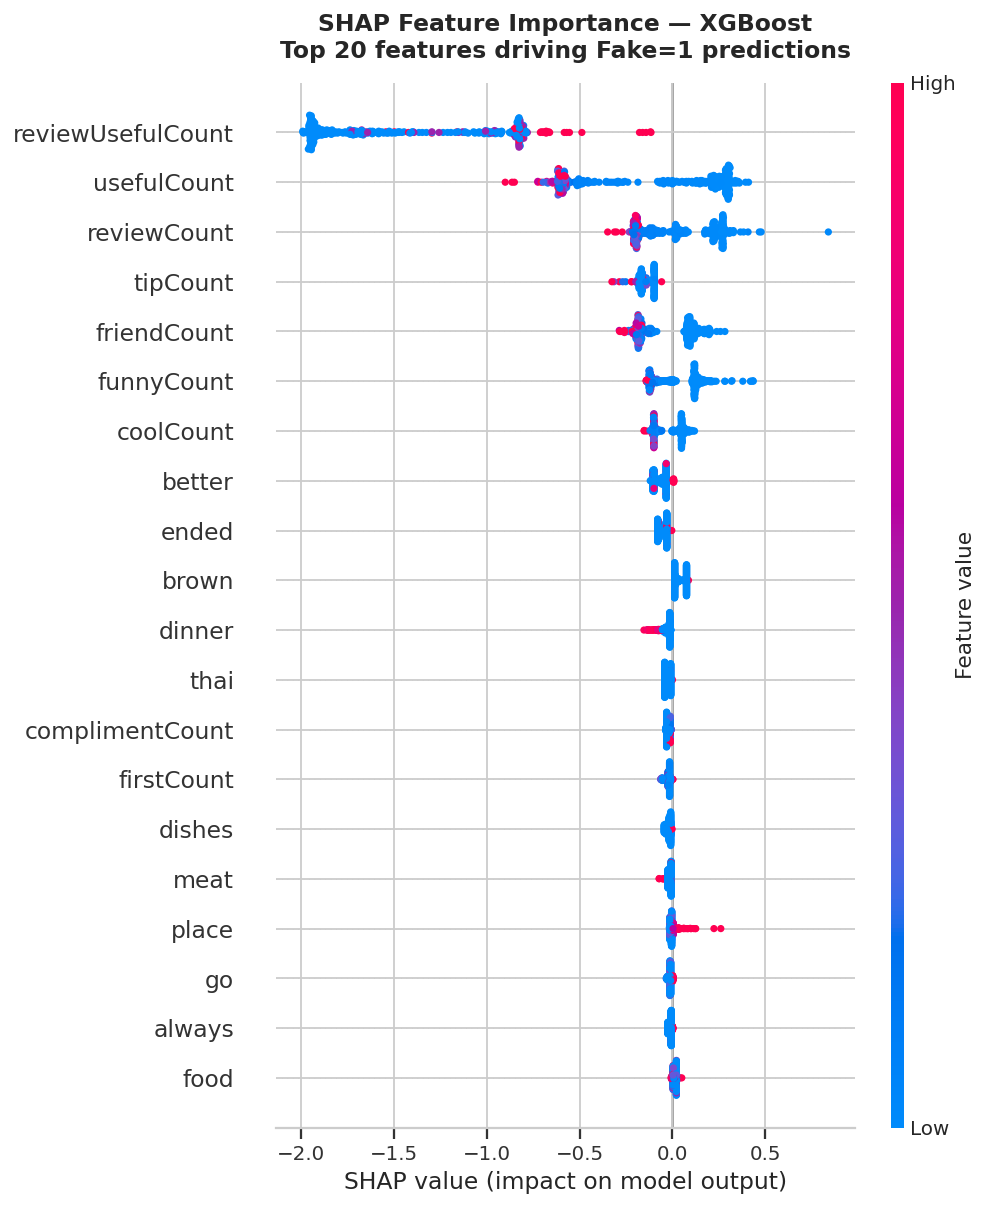

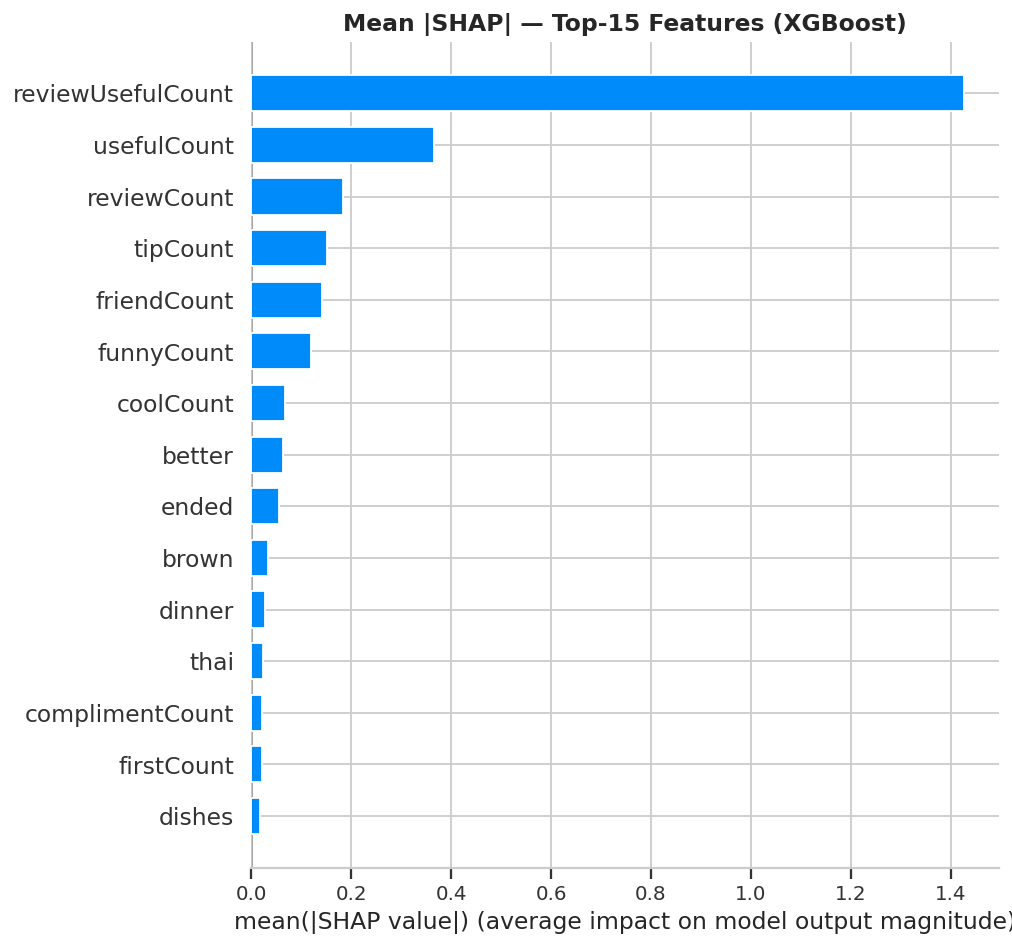

  SHAP plots saved.


In [15]:
TREE_CANDIDATES = ['XGBoost', 'Random Forest']
tree_name = next((n for n in TREE_CANDIDATES if n in tuned_pipelines), None)

if not SHAP_AVAILABLE:
    print("SHAP not installed. Run: pip install shap")
elif tree_name is None:
    print("No tree-based pipeline found.")
else:
    print(f"Running SHAP on: {tree_name}")
    tree_pipe = tuned_pipelines[tree_name]   # use pre-calibration pipeline

    # ── Step 1: transform test data through the pipeline preprocessor ─────────
    Xte_shap = get_X(tree_name, X_test)
    preprocessor = tree_pipe.named_steps['preprocessor']
    X_transformed = preprocessor.transform(Xte_shap)

    # ── Step 2: convert to dense (CRITICAL — prevents SHAP crash on sparse) ───
    if issparse(X_transformed):
        X_dense = X_transformed.toarray()
        print(f"  Sparse -> dense conversion applied. Shape: {X_dense.shape}")
    else:
        X_dense = np.asarray(X_transformed)

    # ── Step 3: build feature name list ───────────────────────────────────────
    tfidf_feat = preprocessor.named_transformers_['text'].get_feature_names_out().tolist()
    feature_names = tfidf_feat + BEHAVIORAL_COLS
    feature_names = feature_names[:X_dense.shape[1]]  # trim if needed

    # ── Step 4: SHAP TreeExplainer ────────────────────────────────────────────
    clf_step = tree_pipe.named_steps['clf']
    explainer = shap.TreeExplainer(clf_step)

    # Sample for speed — full test set can be slow for deep forests
    n_sample  = min(400, len(X_dense))
    rng       = np.random.default_rng(RANDOM_STATE)
    idx_s     = rng.choice(len(X_dense), n_sample, replace=False)
    X_sample  = X_dense[idx_s]

    shap_values = explainer.shap_values(X_sample)

    # For binary classifiers, shap_values may be a list [cls0, cls1]
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    print(f"  SHAP values computed on {n_sample} samples. Shape: {sv.shape}")

    # ── Dot summary plot (top-20) ─────────────────────────────────────────────
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X_sample, feature_names=feature_names,
                      max_display=20, show=False, plot_type='dot')
    plt.title(f'SHAP Feature Importance — {tree_name}\n'
              f'Top 20 features driving Fake=1 predictions',
              fontweight='bold', fontsize=13, pad=14)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'shap_dot.png', bbox_inches='tight', dpi=160)
    plt.show()

    # ── Bar plot (mean |SHAP|) ────────────────────────────────────────────────
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, X_sample, feature_names=feature_names,
                      max_display=15, show=False, plot_type='bar')
    plt.title(f'Mean |SHAP| — Top-15 Features ({tree_name})',
              fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'shap_bar.png', bbox_inches='tight', dpi=160)
    plt.show()
    print("  SHAP plots saved.")

## 14 — Real-World Imbalance Simulation (88 % / 12 %)

> In production, genuine reviews dominate overwhelmingly. Training on
> balanced data, then testing on a skewed partition reveals the **production
> performance gap** — critical for any real deployment decision.
>
> **PR-AUC is the correct primary metric here**, not ROC-AUC.
> ROC-AUC is insensitive to class ratio and overstates performance on
> severely imbalanced data.

  Imbalance Simulation — Test Partition
  Genuine : 243  (88.0%)
  Fake    : 33  (12.0%)
  Total   : 276

  Model: Random Forest  (threshold=0.40)
  F1-Score             : 56.25%
  Precision            : 42.86%
  Recall               : 81.82%
  ROC-AUC              : 89.82%
  Precision-Recall AUC : 50.37%  <- primary metric

  Classification Report (skewed distribution):
              precision    recall  f1-score   support

     Genuine     0.9718    0.8519    0.9079       243
        Fake     0.4286    0.8182    0.5625        33

    accuracy                         0.8478       276
   macro avg     0.7002    0.8350    0.7352       276
weighted avg     0.9069    0.8478    0.8666       276



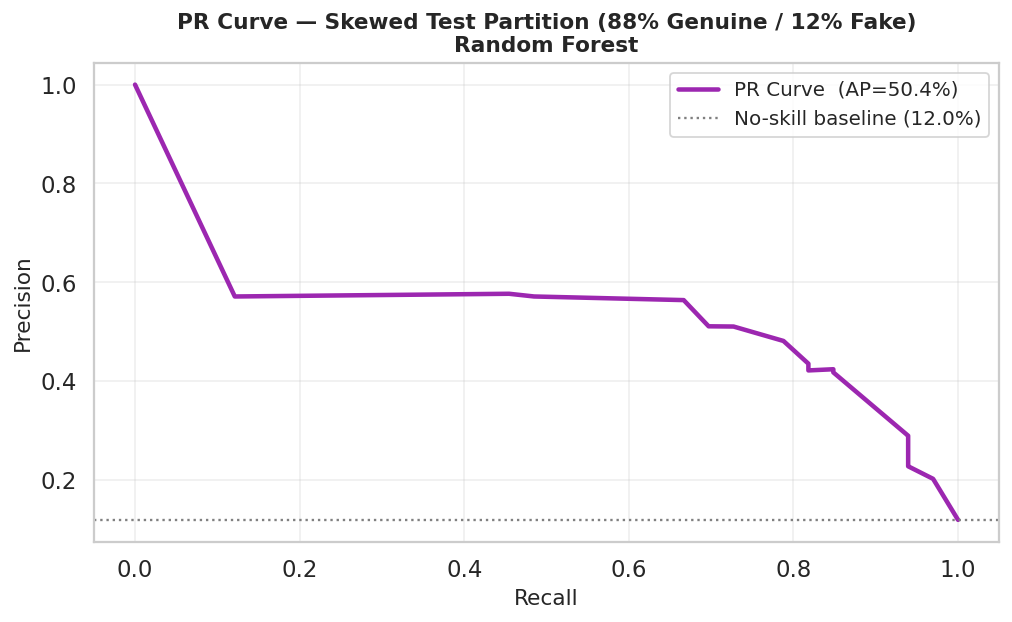


  Performance delta: balanced test -> skewed production test:
  F1-Score : 86.72% -> 56.25%  (delta -30.47%)
  ROC-AUC  : 92.08% -> 89.82%  (delta -2.26%)


In [16]:
GENUINE_PCT = 0.88
FAKE_PCT    = 0.12

genuine_idx = y_test[y_test==0].index.tolist()
fake_idx    = y_test[y_test==1].index.tolist()
n_fake_keep = round(len(genuine_idx) * FAKE_PCT / GENUINE_PCT)
n_fake_keep = min(n_fake_keep, len(fake_idx))

rng_sk = np.random.default_rng(RANDOM_STATE)
fake_sampled = rng_sk.choice(fake_idx, size=n_fake_keep, replace=False).tolist()
skewed_idx   = genuine_idx + fake_sampled
X_skew = X_test.loc[skewed_idx]
y_skew = y_test.loc[skewed_idx]

print("=" * 65)
print("  Imbalance Simulation — Test Partition")
print("=" * 65)
print(f"  Genuine : {(y_skew==0).sum():,}  ({(y_skew==0).sum()/len(y_skew)*100:.1f}%)")
print(f"  Fake    : {(y_skew==1).sum():,}  ({(y_skew==1).sum()/len(y_skew)*100:.1f}%)")
print(f"  Total   : {len(y_skew):,}")

Xsk_best = get_X(BEST_NAME, X_skew)
y_sk_prob = BEST_PIPE.predict_proba(Xsk_best)[:,1] if hasattr(BEST_PIPE,'predict_proba') else None
y_sk_pred = (y_sk_prob >= OPTIMAL_THRESHOLD).astype(int) if y_sk_prob is not None             else BEST_PIPE.predict(Xsk_best)

pr_auc   = average_precision_score(y_skew, y_sk_prob) if y_sk_prob is not None else None
roc_auc_sk = roc_auc_score(y_skew, y_sk_prob)         if y_sk_prob is not None else None

print(f"\n  Model: {BEST_NAME}  (threshold={OPTIMAL_THRESHOLD:.2f})")
print(f"  F1-Score             : {f1_score(y_skew, y_sk_pred, zero_division=0)*100:.2f}%")
print(f"  Precision            : {precision_score(y_skew, y_sk_pred, zero_division=0)*100:.2f}%")
print(f"  Recall               : {recall_score(y_skew, y_sk_pred, zero_division=0)*100:.2f}%")
if roc_auc_sk: print(f"  ROC-AUC              : {roc_auc_sk*100:.2f}%")
if pr_auc:     print(f"  Precision-Recall AUC : {pr_auc*100:.2f}%  <- primary metric")

print("\n  Classification Report (skewed distribution):")
print(classification_report(y_skew, y_sk_pred, target_names=['Genuine','Fake'], digits=4))

# ── PR curve on skewed partition ──────────────────────────────────────────────
if y_sk_prob is not None:
    prec_c, rec_c, _ = precision_recall_curve(y_skew, y_sk_prob)
    baseline = y_skew.mean()
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(rec_c, prec_c, lw=2.5, color='#9C27B0',
            label=f'PR Curve  (AP={pr_auc*100:.1f}%)')
    ax.axhline(baseline, color='gray', ls=':', lw=1.3,
               label=f'No-skill baseline ({baseline*100:.1f}%)')
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'PR Curve — Skewed Test Partition (88% Genuine / 12% Fake)\n{BEST_NAME}',
                 fontweight='bold', fontsize=12)
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'pr_curve_skewed.png', bbox_inches='tight')
    plt.show()

# ── Balanced vs skewed performance delta ──────────────────────────────────────
print("\n  Performance delta: balanced test -> skewed production test:")
bal_f1  = best_result['F1-Score']
sk_f1   = f1_score(y_skew, y_sk_pred, zero_division=0)*100
print(f"  F1-Score : {bal_f1:.2f}% -> {sk_f1:.2f}%  (delta {sk_f1-bal_f1:+.2f}%)")
if best_result['ROC-AUC'] and roc_auc_sk:
    print(f"  ROC-AUC  : {best_result['ROC-AUC']:.2f}% -> {roc_auc_sk*100:.2f}%  "
          f"(delta {roc_auc_sk*100-best_result['ROC-AUC']:+.2f}%)")

## 15 — Production Artefact Serialisation

In [18]:
print("=" * 65)
print("  Saving Artefacts")
print("=" * 65)

# 1. Best complete pipeline (preprocessor + calibrated clf)
pipe_path = MDL_DIR / 'best_pipeline.joblib'
joblib.dump(BEST_PIPE, pipe_path, compress=3)
print(f"  Best pipeline       -> {pipe_path}")

# 2. All calibrated pipelines
for name, pipe in calibrated_pipelines.items():
    safe = name.replace(' ','_').replace('(','').replace(')','').replace('/','_')
    joblib.dump(pipe, MDL_DIR / f'pipeline_{safe}.joblib', compress=3)
print(f"  All pipelines       -> {MDL_DIR}/")

# 3. Test predictions (final model, optimal threshold)
preds_out = X_test[[TEXT_COL]].copy()
preds_out['true_label']    = y_test.values
preds_out['predicted']     = best_result['_pred']
if best_result['_prob'] is not None:
    preds_out['pred_prob_fake'] = (np.array(best_result['_prob'])*1000).round()/1000
preds_out['correct'] = preds_out['true_label'] == preds_out['predicted']
preds_path = BASE_OUT / 'test_predictions.csv'
preds_out.to_csv(preds_path)
print(f"  Test predictions    -> {preds_path}")

# 4. Comprehensive metrics JSON
sk_f1_val  = f1_score(y_skew, y_sk_pred, zero_division=0)
sk_pr_val  = precision_score(y_skew, y_sk_pred, zero_division=0)
sk_rec_val = recall_score(y_skew, y_sk_pred, zero_division=0)

# CRITICAL FIX: Safely parse values for JSON, avoiding converting string model names to float
balanced_test_clean = {}
for k, v in best_result.items():
    if k.startswith('_'):
        continue
    # If the value is already a float/int, keep it. Otherwise check if it can be a float.
    if isinstance(v, (int, float)):
        balanced_test_clean[k] = float(v)
    elif isinstance(v, str):
        try:
            balanced_test_clean[k] = float(v.replace('%', '').strip())
        except ValueError:
            balanced_test_clean[k] = v # Keeps 'Random Forest' or 'XGBoost' as a string safely
    else:
        balanced_test_clean[k] = v

metrics_payload = {
    'timestamp'        : datetime.now().isoformat(),
    'best_model'       : BEST_NAME,
    'optimal_threshold': round(float(OPTIMAL_THRESHOLD), 4),
    'config': {
        'random_state': RANDOM_STATE, 'test_size': TEST_SIZE,
        'val_size': VAL_SIZE, 'cv_folds': CV_FOLDS,
        'max_tfidf_features': MAX_TFIDF_FEAT,
        'behavioral_cols': BEHAVIORAL_COLS,
    },
    'ablation_cv': {
        k: {m: round(v*100,2) for m,v in vs.items()}
        for k,vs in ablation_results.items()
    },
    'cross_validation': cv_df.to_dict(orient='records'),
    'balanced_test': balanced_test_clean, # Uses the safely parsed clean dictionary
    'skewed_test_88_12': {
        'genuine_pct' : GENUINE_PCT,
        'fake_pct'    : FAKE_PCT,
        'F1'          : round(sk_f1_val*100, 2),
        'Precision'   : round(sk_pr_val*100, 2),
        'Recall'      : round(sk_rec_val*100, 2),
        'ROC_AUC'     : round(roc_auc_sk*100, 2) if roc_auc_sk else None,
        'PR_AUC'      : round(pr_auc*100, 2)      if pr_auc     else None,
    },
    'error_analysis': {
        'false_positives': int(len(fp_df)),
        'false_negatives': int(len(fn_df)),
        'fp_csv': str(ERR_DIR / 'false_positives.csv'),
        'fn_csv': str(ERR_DIR / 'false_negatives.csv'),
    },
    'artefact_paths': {
        'best_pipeline'   : str(pipe_path),
        'test_predictions': str(preds_path),
        'plots'           : str(PLOT_DIR),
    }
}

metrics_path = BASE_OUT / 'metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics_payload, f, indent=2)
print(f"  metrics.json        -> {metrics_path}")

print("\n" + "=" * 65)
print("  ALL ARTEFACTS SAVED SUCCESSFULLY")
print("=" * 65)

  Saving Artefacts
  Best pipeline       -> outputs_final/models/best_pipeline.joblib
  All pipelines       -> outputs_final/models/
  Test predictions    -> outputs_final/test_predictions.csv
  metrics.json        -> outputs_final/metrics.json

  ALL ARTEFACTS SAVED SUCCESSFULLY


## 16 — Final Summary

In [19]:
print("=" * 65)
print("  FAKE REVIEW DETECTION — FINAL RESULTS")
print("=" * 65)
print(f"  Dataset      : YelpChi ({len(df):,} reviews)")
print(f"  Best model   : {BEST_NAME}")
print(f"  Threshold    : {OPTIMAL_THRESHOLD:.2f}  (optimised on val PR frontier)")
print()
print("  Ablation (Logistic Regression, 5-fold CV):")
for cfg, vals in ablation_results.items():
    print(f"    {cfg:<22}: F1={vals['F1']*100:.2f}%  AUC={vals['AUC']*100:.2f}%")
print()
print("  Test metrics (balanced ~50/50):")
for k in ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']:
    v = best_result.get(k)
    if v is not None:
        print(f"    {k:<14}: {v:.2f}%")
print()
print("  Skewed test (88% Genuine / 12% Fake):")
print(f"    F1-Score  : {f1_score(y_skew,y_sk_pred,zero_division=0)*100:.2f}%")
if pr_auc:
    print(f"    PR-AUC    : {pr_auc*100:.2f}%")
print()
print("  Artefacts:")
print(f"    {BASE_OUT.resolve()}/")
print("      metrics.json           — complete experiment record")
print("      test_predictions.csv   — per-sample predictions")
print("      models/                — serialised pipelines")
print("      plots/                 — all publication-quality figures")
print("      error_analysis/        — FP / FN CSV exports")
print("=" * 65)

  FAKE REVIEW DETECTION — FINAL RESULTS
  Dataset      : YelpChi (2,483 reviews)
  Best model   : Random Forest
  Threshold    : 0.40  (optimised on val PR frontier)

  Ablation (Logistic Regression, 5-fold CV):
    Text-only             : F1=62.61%  AUC=66.58%
    Behavioral-only       : F1=78.88%  AUC=90.89%
    Fusion (combined)     : F1=74.97%  AUC=90.88%

  Test metrics (balanced ~50/50):
    Accuracy      : 86.32%
    Precision     : 86.05%
    Recall        : 87.40%
    F1-Score      : 86.72%
    ROC-AUC       : 92.08%

  Skewed test (88% Genuine / 12% Fake):
    F1-Score  : 56.25%
    PR-AUC    : 50.37%

  Artefacts:
    /content/outputs_final/
      metrics.json           — complete experiment record
      test_predictions.csv   — per-sample predictions
      models/                — serialised pipelines
      plots/                 — all publication-quality figures
      error_analysis/        — FP / FN CSV exports


---
## Appendix — Inference with the Saved Pipeline

```python
import joblib, pandas as pd

# Load the complete pipeline (preprocessor + calibrated classifier)
pipeline = joblib.load('outputs_final/models/best_pipeline.joblib')

# For fusion pipelines, pass a DataFrame with all required columns.
# Column names must exactly match those used during training.
new_review = pd.DataFrame([{
    'reviewContent'   : 'Amazing place! Will definitely come back.',
    'friendCount'     : 0,    'reviewCount'      : 1,
    'firstCount'      : 1,    'usefulCount'      : 0,
    'coolCount'       : 0,    'funnyCount'        : 0,
    'complimentCount' : 0,    'tipCount'          : 0,
    'fanCount'        : 0,    'reviewUsefulCount' : 0,
    'rating'          : 5.0,  'restaurantRating'  : 4.0,
}])

prob  = pipeline.predict_proba(new_review)[0, 1]
label = 'FAKE' if prob >= 0.5 else 'GENUINE'   # replace 0.5 with OPTIMAL_THRESHOLD
print(f"Prediction: {label}  (P(fake) = {prob:.3f})")
```